## Import the Necessary Libraries

Found 9866 images belonging to 11 classes.
Found 3430 images belonging to 11 classes.
Found 3347 images belonging to 11 classes.
Epoch 1/3
309/309 ━━━━━━━━━━━━━━━━━━━━ 151s 455ms/step - accuracy: 0.5056 - loss: 1.5612 - val_accuracy: 0.7810 - val_loss: 0.7035 - learning_rate: 0.0010
Epoch 2/3
309/309 ━━━━━━━━━━━━━━━━━━━━ 140s 444ms/step - accuracy: 0.7030 - loss: 0.9022 - val_accuracy: 0.7968 - val_loss: 0.6458 - learning_rate: 0.0010
Epoch 3/3
309/309 ━━━━━━━━━━━━━━━━━━━━ 140s 443ms/step - accuracy: 0.7334 - loss: 0.7989 - val_accuracy: 0.8120 - val_loss: 0.5988 - learning_rate: 0.0010
Epoch 1/3
309/309 ━━━━━━━━━━━━━━━━━━━━ 160s 470ms/step - accuracy: 0.6443 - loss: 1.1741 - val_accuracy: 0.8111 - val_loss: 0.5942 - learning_rate: 1.0000e-05
Epoch 2/3
309/309 ━━━━━━━━━━━━━━━━━━━━ 142s 450ms/step - accuracy: 0.7366 - loss: 0.7970 - val_accuracy: 0.8190 - val_loss: 0.5802 - learning_rate: 1.0000e-05
Epoch 3/3
309/309 ━━━━━━━━━━━━━━━━━━━━ 141s 449ms/step - accuracy: 0.7549 - loss: 0.7358

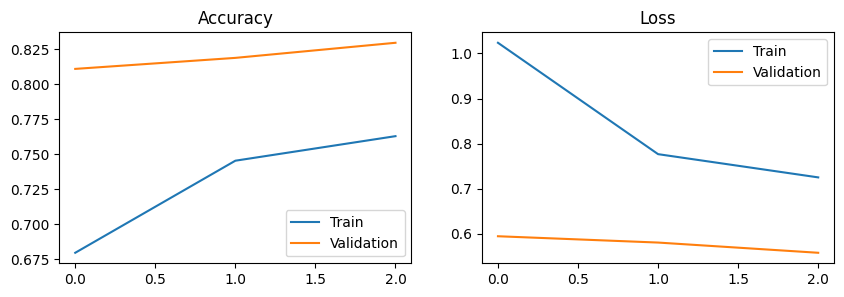

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted: Bread
Confidence: 0.41


In [9]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Data Augmentation
# -----------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    shear_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    rotation_range=25,
    horizontal_flip=True,
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# -----------------------------
# Load Dataset
# -----------------------------
train_dataset = train_datagen.flow_from_directory(
    '/kaggle/input/food11-image-dataset/training',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True,
)

valid_dataset = valid_datagen.flow_from_directory(
    '/kaggle/input/food11-image-dataset/validation',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
)

test_dataset = test_datagen.flow_from_directory(
    '/kaggle/input/food11-image-dataset/evaluation',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
)

# -----------------------------
# Base Model
# -----------------------------
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# -----------------------------
# Custom Layers
# -----------------------------
x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(11, activation='softmax')(x)

model = tf.keras.Model(inputs=base_model.input, outputs=output)

# -----------------------------
# Callbacks
# -----------------------------
lr_callback = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.3)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

# -----------------------------
# Compile & Train (Phase 1)
# -----------------------------
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=3,  # increased
    callbacks=[lr_callback, checkpoint]
)

# -----------------------------
# Fine-Tuning
# -----------------------------
for layer in base_model.layers[:-20]:
    layer.trainable = False
for layer in base_model.layers[-20:]:
    layer.trainable = True

model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    metrics=['accuracy']
)

history_tune = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=3,
    callbacks=[lr_callback, checkpoint]
)

model.save('final_model.keras')

# -----------------------------
# Evaluation
# -----------------------------
print("\n--- Evaluation ---")
train_result = model.evaluate(train_dataset)
val_result = model.evaluate(valid_dataset)
test_result = model.evaluate(test_dataset)

print('Train Accuracy:', train_result[1])
print('Validation Accuracy:', val_result[1])
print('Test Accuracy:', test_result[1])

# -----------------------------
# Graphs
# -----------------------------
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.title('Accuracy')
plt.plot(history_tune.history['accuracy'], label='Train')
plt.plot(history_tune.history['val_accuracy'], label='Validation')
plt.legend()

plt.subplot(1, 2, 2)
plt.title('Loss')
plt.plot(history_tune.history['loss'], label='Train')
plt.plot(history_tune.history['val_loss'], label='Validation')
plt.legend()

plt.show()

# -----------------------------
# 🔥 NEW: Prediction Code (IMPORTANT)
# -----------------------------
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    class_indices = train_dataset.class_indices
    classes = list(class_indices.keys())

    predicted_class = classes[np.argmax(prediction)]
    confidence = np.max(prediction)

    print(f"Predicted: {predicted_class}")
    print(f"Confidence: {confidence:.2f}")

# 👉 Example usage:
predict_image('/kaggle/input/food11-image-dataset/evaluation/Bread/100.jpg')